# ERpncoding

In [1]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout, DepthwiseConv2D
import tensorflow as tf

In [2]:
# Opciones de decodificación para otros parámetros
layer_type_options = {
    0: 'Conv2D', 
    1: 'BatchNorm', 
    2: 'MaxPooling', 
    3: 'Dropout', 
    4: 'Dense', 
    5: 'Flatten',
    6: 'DepthwiseConv2D',  
    7: 'DontCare',  
    8: 'Repetition'
}
stride_options = {0: 1, 1: 2}
dropout_options = {0: 0.2, 1: 0.3, 2: 0.4, 3: 0.5}
activation_options = {0: 'relu', 1: 'leaky_relu', 2: 'sigmoid', 3: 'tanh'}

# Función para codificar los parámetros de la capa
def encode_layer_params(layer_type_idx, param1=0, param2=0, param3=0):
    """
    Codifica una capa en una lista en función del tipo de capa y sus parámetros.
    
    layer_type_idx : int : índice del tipo de capa según layer_type_options.
    param1         : int/float : filtros, neuronas, capas de repetición, etc.
    param2         : int : stride, número de repeticiones, etc.
    param3         : int : índice de activación o tasa de dropout.
    """
    return [layer_type_idx, param1, param2, param3]

# Función para decodificar los parámetros de la capa
def decode_layer_params(encoded_params):
    """
    Decodifica una capa desde su representación codificada en parámetros interpretables.
    
    encoded_params : list : [tipo de capa, param1, param2, param3].
    """
    layer_type_idx = encoded_params[0]
    layer_type = layer_type_options.get(layer_type_idx, 'DontCare')
    
    # Decodificar en función del tipo de capa
    if layer_type in ['Conv2D', 'DepthwiseConv2D']:
        filters = max(4, min(encoded_params[1], 32))  # Limitar filtros entre 4 y 32
        strides = stride_options.get(encoded_params[2], 1)
        activation = activation_options.get(encoded_params[3], 'relu')
        return {
            'type': layer_type,
            'filters': filters,
            'strides': strides,
            'activation': activation
        }
    elif layer_type == 'BatchNorm':
        return {'type': 'BatchNorm'}
    elif layer_type == 'MaxPooling':
        strides = stride_options.get(encoded_params[1], 1)
        return {'type': 'MaxPooling', 'strides': strides}
    elif layer_type == 'Dropout':
        rate = dropout_options.get(encoded_params[1], 0.2)
        return {'type': 'Dropout', 'rate': rate}
    elif layer_type == 'Dense':
        units = max(1, min(encoded_params[1], 512))  # Limitar unidades entre 1 y 512
        activation = activation_options.get(encoded_params[2], 'relu')
        return {'type': 'Dense', 'units': units, 'activation': activation}
    elif layer_type == 'Flatten':
        return {'type': 'Flatten'}
    elif layer_type == 'Repetition':
        return {
            'type': 'Repetition',
            'repetition_layers': int(encoded_params[1]),
            'repetition_count': int(encoded_params[2])
        }
    elif layer_type == 'DontCare':
        return {'type': "DontCare"}

    return None



## Complete archs


In [3]:
# Clase para capas neutrales 'DontCare'
class DontCareLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(DontCareLayer, self).__init__()

    def call(self, inputs):
        return inputs

In [4]:
def encode_model_architecture(model_dict, max_alleles=48):
    """
    Codifica la arquitectura del modelo en una lista de valores con un máximo de `max_alleles`.
    Cada capa se codifica en función de sus parámetros.
    """
    encoded_layers = []
    total_alleles = 0

    for layer in model_dict['layers']:
        if layer['type'] == 'Repetition':  # Codificar capa de repetición
            encoded_layer = encode_layer_params(
                layer_type_idx=8,  # índice para 'Repetition'
                param1=layer.get('repetition_layers', 0),
                param2=layer.get('repetition_count', 1)
            )
        else:
            layer_type_idx = next(
                key for key, value in layer_type_options.items() if value == layer['type']
            )
            
            # Codificar parámetros específicos de cada tipo de capa
            if layer['type'] in ['Conv2D', 'DepthwiseConv2D']:  
                # Limitar filtros dentro del rango [4, 32]
                param1 = max(4, min(layer.get('filters', 8), 32))  
                param2 = next((key for key, value in stride_options.items() if value == layer.get('strides', 1.0)), 0)
                param3 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, param3]

            elif layer['type'] == 'Dense':
                # Limitar neuronas dentro del rango [1, 512]
                param1 = max(1, min(layer.get('units', 1), 512))
                param2 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, 0]

            elif layer['type'] == 'MaxPooling':
                param1 = next((key for key, value in stride_options.items() if value == layer.get('strides', 1.0)), 0)
                encoded_layer = [layer_type_idx, param1, 0, 0]

            elif layer['type'] == 'Dropout':
                param1 = next((key for key, value in dropout_options.items() if value == layer.get('rate', 0.2)), 0)
                encoded_layer = [layer_type_idx, param1, 0, 0]

            elif layer['type'] == 'BatchNorm':
                encoded_layer = [layer_type_idx, 0, 0, 0]

            elif layer['type'] == 'Flatten':
                encoded_layer = [layer_type_idx, 0, 0, 0]

            elif layer['type'] == 'DontCare':
                encoded_layer = [layer_type_idx, 0, 0, 0]

        # Añadir la codificación de la capa a la lista de alelos
        encoded_layers.extend(encoded_layer)
        total_alleles += len(encoded_layer)

    # Rellenar con 'DontCare' si el total de alelos es menor que `max_alleles`
    while total_alleles < max_alleles:
        dont_care_encoding = encode_layer_params(7)  # índice de 'DontCare'
        encoded_layers.extend(dont_care_encoding)
        total_alleles += len(dont_care_encoding)

    # Recortar si excede `max_alleles`
    final_encoding = encoded_layers[:max_alleles]
    print(f"Final Encoded Model: {final_encoding}")
    
    return final_encoding


In [5]:
import random

def fixArch(encoded_model, verbose=False):
    """
    Corrige la arquitectura codificada del modelo, asegurando que:
    - Se evite la presencia de capas incompatibles después de una capa Flatten.
    - En caso de una capa de Repetition, se ajuste el alcance de repetición si no hay suficientes capas anteriores.

    Parameters:
        encoded_model (list): Lista codificada de la arquitectura del modelo.
        verbose (bool): Si es True, muestra las correcciones realizadas.

    Returns:
        list: Lista con la arquitectura corregida, truncada a un máximo de 48 alelos.
    """

    fixed_layers = []  # Lista que almacenará la arquitectura corregida
    input_is_flattened = False  # Indicador para saber si ya hay una capa Flatten en el modelo
    index = 0  # Índice para recorrer el modelo codificado

    # Procesar cada capa en el modelo sin forzar la primera capa a ser específica
    while index < len(encoded_model) and len(fixed_layers) < 48:
        layer_type = int(encoded_model[index])  # Obtener el tipo de capa actual

        # Procesar la capa de Repetition
        if layer_type == 8:
            repetition_layers = int(encoded_model[index + 1])  # Número de capas a repetir
            repetition_count = min(max(int(encoded_model[index + 2]), 0), 32)  # Cantidad de repeticiones

            # Verificar si hay suficientes capas para la repetición solicitada
            actual_layers_to_repeat = min(repetition_layers, len(fixed_layers) // 4)

            if actual_layers_to_repeat != repetition_layers:
                if verbose:
                    print(f"Ajustando alcance de repetición de {repetition_layers} a {actual_layers_to_repeat} debido a falta de capas.")
                repetition_layers = actual_layers_to_repeat

            # Añadir la capa de repetición sin modificar su estructura
            fixed_layers.extend([layer_type, repetition_layers, repetition_count, 0])
            index += 4
            continue

        # Procesar cada tipo de capa normal con sus restricciones
        if layer_type == 0:  # Conv2D
            if input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])  # DontCare
            else:
                # Limitar el número de filtros entre 4 y 32
                filters = min(max(int(encoded_model[index + 1]), 4), 32)
                stride_idx = min(max(int(encoded_model[index + 2]), 0), 1)
                activation_idx = min(max(int(encoded_model[index + 3]), 0), 3)
                fixed_layers.extend([layer_type, filters, stride_idx, activation_idx])

        elif layer_type == 6:  # DepthwiseConv2D
            if input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])  # DontCare
            else:
                # Limitar el número de filtros entre 4 y 32
                filters = min(max(int(encoded_model[index + 1]), 4), 32)
                stride_idx = min(max(int(encoded_model[index + 2]), 0), 1)
                activation_idx = min(max(int(encoded_model[index + 3]), 0), 3)
                fixed_layers.extend([layer_type, filters, stride_idx, activation_idx])

        elif layer_type == 2:  # MaxPooling
            if input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])  # DontCare
            else:
                stride_idx = min(max(int(encoded_model[index + 1]), 0), 1)
                fixed_layers.extend([layer_type, stride_idx, 0, 0])

        elif layer_type == 3:  # Dropout
            rate_idx = min(max(int(encoded_model[index + 1]), 0), 3)
            fixed_layers.extend([layer_type, rate_idx, 0, 0])

        elif layer_type == 4:  # Dense
            # Limitar el número de neuronas entre 1 y 512
            neurons = min(max(int(encoded_model[index + 1]), 1), 512)
            activation_idx = min(max(int(encoded_model[index + 2]), 0), 3)
            fixed_layers.extend([layer_type, neurons, activation_idx, 0])

        elif layer_type == 1:  # BatchNorm
            fixed_layers.extend([layer_type, 0, 0, 0])

        elif layer_type == 5:  # Flatten
            if len(fixed_layers) < 16:
                fixed_layers.extend([7, 0, 0, 0])  # DontCare
            elif input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])  # DontCare
            else:
                fixed_layers.extend([layer_type, 0, 0, 0])
                input_is_flattened = True  # Marcar que ya hay un Flatten

        elif layer_type == 7:  # DontCare
            fixed_layers.extend([layer_type, 0, 0, 0])

        else: # DontCare
          fixed_layers.extend([7, 0, 0, 0])

        index += 4  # Avanzar al siguiente grupo de parámetros

    return fixed_layers[:48]  # Limitar a 48 alelos


In [6]:
def decode_model_architecture(encoded_model):
    """
    Decodifica la arquitectura del modelo a partir de la lista codificada de valores (índices),
    aplicando las reglas de repetición y asegurando la inclusión de una capa convolucional inicial.
    """
    model_dict = {'layers': [{'type': 'Conv2D', 'filters': 32, 'strides': 1, 'activation': 'relu'}]}  # Inserta Conv2D inicial
    index = 0

    while index < len(encoded_model):
        layer_type = int(encoded_model[index])
        param1 = encoded_model[index + 1]
        param2 = encoded_model[index + 2]
        param3 = encoded_model[index + 3]

        if layer_type == 8:  # Capa de Repetition
            repetition_layers = int(param1)
            repetition_count = int(param2)
            # Selecciona solo el grupo válido de capas para la repetición
            layers_to_repeat = select_group_for_repetition(model_dict['layers'], repetition_layers)
            
            if len(layers_to_repeat) > 0:
                for _ in range(repetition_count):
                    model_dict['layers'].extend(layers_to_repeat)

        else:
            decoded_layer = {}

            if layer_type == 0:  # Conv2D
                decoded_layer = {
                    'type': 'Conv2D',
                    'filters': max(4, min(param1, 32)),  # Limita `filters` entre 4 y 32
                    'strides': stride_options.get(param2, 1),
                    'activation': activation_options.get(param3, 'relu')
                }
            elif layer_type == 6:  # DepthwiseConv2D
                decoded_layer = {
                    'type': 'DepthwiseConv2D',
                    'filters': max(4, min(param1, 32)),  # Limita `filters` entre 4 y 32
                    'strides': stride_options.get(param2, 1),
                    'activation': activation_options.get(param3, 'relu')
                }
            elif layer_type == 2:  # MaxPooling
                decoded_layer = {
                    'type': 'MaxPooling',
                    'strides': stride_options.get(param1, 1)
                }
            elif layer_type == 3:  # Dropout
                decoded_layer = {
                    'type': 'Dropout',
                    'rate': dropout_options.get(param1, 0.2)
                }
            elif layer_type == 4:  # Dense
                decoded_layer = {
                    'type': 'Dense',
                    'units': max(1, min(param1, 512)),  # Limita `units` entre 1 y 512
                    'activation': activation_options.get(param2, 'relu')
                }
            elif layer_type == 1:  # BatchNorm
                decoded_layer = {'type': 'BatchNorm'}
            elif layer_type == 5:  # Flatten
                decoded_layer = {'type': 'Flatten'}
            elif layer_type == 7:  # DontCare
                decoded_layer = {'type': 'DontCare'}

            model_dict['layers'].append(decoded_layer)

        index += 4

    # Asegura que haya una capa Flatten antes de la capa Dense final, si no ya existe una Flatten
    if model_dict['layers'][-1]['type'] != 'Flatten':
        model_dict['layers'].append({'type': 'Flatten'})
        
    # Añade la capa Dense final obligatoria
    model_dict['layers'].append({'type': 'Dense', 'units': 1, 'activation': 'sigmoid'})

    return model_dict

def select_group_for_repetition(layers, repetition_layers):
    """
    Selecciona el primer grupo válido para repetición en función de las reglas de compatibilidad.

    Parameters:
        layers (list): Lista de capas ya procesadas, donde cada capa es un diccionario.
        repetition_layers (int): Número de capas hacia atrás para considerar en la repetición.

    Returns:
        list: Lista de capas compatibles para repetición.
    """
    valid_layers = []
    group_type = None

    # Retrocede desde el final de `layers` para encontrar el grupo válido
    for layer in reversed(layers[-repetition_layers:]):
        if group_type is None:
            # Determina el tipo de grupo
            if layer['type'] in ['Flatten', 'Dense']:
                group_type = 'dense'
                valid_layers.insert(0, layer)
            elif layer['type'] in ['Conv2D', 'DepthwiseConv2D', 'MaxPooling']:
                group_type = 'convolutional'
                valid_layers.insert(0, layer)
            elif layer['type'] in ['BatchNorm', 'DontCare']:  # BatchNorm y DontCare son compatibles con ambos grupos
                valid_layers.insert(0, layer)
        else:
            # Agrega solo capas compatibles con el grupo seleccionado
            if group_type == 'dense' and layer['type'] in ['Flatten', 'Dense', 'BatchNorm', 'DontCare']:
                valid_layers.insert(0, layer)
            elif group_type == 'convolutional' and layer['type'] in ['Conv2D', 'DepthwiseConv2D', 'MaxPooling', 'BatchNorm', 'DontCare']:
                valid_layers.insert(0, layer)

    return valid_layers


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Flatten, Dropout, BatchNormalization, DepthwiseConv2D



def build_tf_model_from_dict(model_dict, input_shape=(28, 28, 3)):
    """
    Construye un modelo de TensorFlow a partir de un diccionario JSON expandido.
    """
    print("\nConstruyendo el modelo en TensorFlow desde el JSON expandido...")
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=input_shape))

    for layer in model_dict['layers']:
        if layer['type'] == 'Conv2D':
            model.add(Conv2D(filters=layer['filters'], kernel_size=(3, 3), strides=int(layer['strides']), padding='same', activation=layer['activation']))
        
        elif layer['type'] == 'DepthwiseConv2D':
            model.add(DepthwiseConv2D(kernel_size=(3, 3), strides=int(layer['strides']), padding='same', activation=layer['activation']))
        
        elif layer['type'] == 'BatchNorm':
            model.add(BatchNormalization())
        
        elif layer['type'] == 'MaxPooling':
            model.add(MaxPooling2D(pool_size=(2, 2), strides=int(layer['strides']), padding='same'))
        
        elif layer['type'] == 'Flatten':
            model.add(Flatten())
        
        elif layer['type'] == 'Dense':
            model.add(Dense(units=int(layer['units']), activation=layer['activation']))
        
        elif layer['type'] == 'Dropout':
            model.add(Dropout(rate=layer['rate']))
        
        elif layer['type'] == 'DontCare':
            model.add(DontCareLayer())
    
    return model


In [9]:
def process_model_pipeline(model_dict, input_shape=(28, 28, 3), verbose=False):
    """
    Procesa el pipeline de creación del modelo desde el JSON inicial hasta el modelo de TensorFlow.
    
    Parameters:
        model_dict (dict): Modelo en formato JSON.
        input_shape (tuple): Forma de entrada para el modelo.
        verbose (bool): Si es True, muestra los detalles de cada etapa del proceso.
        
    Returns:
        tf.keras.Model: El modelo de TensorFlow construido a partir del JSON procesado.
    """
    # Codificar el modelo
    encoded_model = encode_model_architecture(model_dict, max_alleles=48)
    if verbose:
        print(f"\nModelo codificado: {encoded_model}")

    # Reparar el modelo codificado
    fixed_model = fixArch(encoded_model, verbose=verbose)
    if verbose:
        print(f"\nModelo codificado y reparado: {fixed_model}")

    # Decodificar el modelo reparado
    decoded_model = decode_model_architecture(fixed_model)
    if verbose:
        print(f"\nModelo decodificado:\n{decoded_model}")

    # Construir el modelo de TensorFlow
    tf_model = build_tf_model_from_dict(decoded_model, input_shape=input_shape)
    if verbose:
        print("\nModelo de TensorFlow construido.")
        tf_model.summary()
    
    return tf_model


# Ejemplo de uso con un modelo y verbose activado



# Testing random generated architectures


In [8]:
import csv
import numpy as np
from pyDOE2 import lhs

# Función para generar un hipercubo latino con rangos normalizados [0, 1]
def generate_latin_hypercube_samples(num_samples, dimensions):
    return lhs(dimensions, samples=num_samples)

# Validar si los parámetros generados están dentro del rango esperado
def validate_latin_hypercube(num_models=100):
    dimensions = 12 * 3  # 12 capas, 3 parámetros por capa
    latin_samples = generate_latin_hypercube_samples(num_models, dimensions)
    
    # Validar cada muestra generada
    for sample_idx, sample in enumerate(latin_samples):
        reshaped_sample = sample.reshape(12, 3)  # Cada modelo tiene 12 capas
        
        for layer_idx, layer_params in enumerate(reshaped_sample):
            # Validar parámetros individuales
            type_idx = int(layer_params[0] * 9)  # 9 tipos de capas
            param1 = layer_params[1]
            param2 = layer_params[2]

            # Verificar tipo de capa
            if type_idx not in range(9):
                print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Tipo inválido {type_idx}")
                return False

            # Verificar rangos específicos según el tipo de capa
            layer_mapping = ['Conv2D', 'DepthwiseConv2D', 'BatchNorm', 'MaxPooling', 
                             'Dropout', 'Dense', 'Flatten', 'DontCare', 'Repetition']
            layer_type = layer_mapping[type_idx]

            if layer_type in ['Conv2D', 'DepthwiseConv2D']:
                filters = int(param1 * (32 - 4) + 4)  # Filtros entre [4, 32]
                if not (4 <= filters <= 32):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Filtros fuera de rango {filters}")
                    return False

            elif layer_type == 'Dropout':
                rate = param1 * (0.5 - 0.2) + 0.2  # Tasa de dropout entre [0.2, 0.5]
                if not (0.2 <= rate <= 0.5):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Dropout fuera de rango {rate}")
                    return False

            elif layer_type == 'Dense':
                units = int(param1 * (512 - 1) + 1)  # Unidades entre [1, 512]
                if not (1 <= units <= 512):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Unidades fuera de rango {units}")
                    return False

    print("Validación completada: Todas las muestras están dentro de los rangos esperados.")
    return True

# Guardar el encoding generado en un archivo CSV
def save_encoded_models_to_csv(num_models, filename, max_alleles=48):
    # Generar muestras de hipercubo latino
    latin_samples = generate_latin_hypercube_samples(num_models, 12 * 3)  # 12 capas, 3 parámetros por capa

    # Crear el archivo CSV
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Escribir encabezados
        writer.writerow(["Model", "Encoded Chromosome"])

        for model_idx in range(num_models):
            # Cada modelo tiene 12 capas
            model_samples = latin_samples[model_idx].reshape(12, 3)

            # Mapear cada muestra a un modelo (JSON)
            model_dict = {
                "layers": [
                    map_to_architecture_params(sample) for sample in model_samples
                ]
            }

            # Realizar el encoding del modelo
            encoded_chromosome = encode_model_architecture(model_dict, max_alleles=max_alleles)

            # Guardar en el archivo CSV
            writer.writerow([model_idx + 1, encoded_chromosome])

    print(f"Cromosomas codificados guardados en {filename}")
    

# Mapear valores normalizados a arquitecturas
def map_to_architecture_params(latin_hypercube_sample):
    layer_type = int(latin_hypercube_sample[0] * 9)  # 9 tipos de capas
    layer_mapping = ['Conv2D', 'DepthwiseConv2D', 'BatchNorm', 'MaxPooling', 
                     'Dropout', 'Dense', 'Flatten', 'DontCare', 'Repetition']

    layer_type_name = layer_mapping[layer_type]

    if layer_type_name == 'Conv2D':
        return {
            "type": "Conv2D",
            "filters": int(latin_hypercube_sample[1] * (16 - 4) + 4),  # [4, 16]
            "strides": 1 if latin_hypercube_sample[2] < 0.5 else 2,
            "activation": "relu"
        }
    elif layer_type_name == 'DepthwiseConv2D':
        return {
            "type": "DepthwiseConv2D",
            "filters": int(latin_hypercube_sample[1] * (16 - 4) + 4),
            "strides": 1 if latin_hypercube_sample[2] < 0.5 else 2,
            "activation": "relu"
        }
    elif layer_type_name == 'BatchNorm':
        return {"type": "BatchNorm"}
    elif layer_type_name == 'MaxPooling':
        return {"type": "MaxPooling", "strides": 1 if latin_hypercube_sample[1] < 0.5 else 2}
    elif layer_type_name == 'Dropout':
        return {"type": "Dropout", "rate": latin_hypercube_sample[1] * (0.5 - 0.2) + 0.2}
    elif layer_type_name == 'Dense':
        return {
            "type": "Dense",
            "units": int(latin_hypercube_sample[1] * (128 - 1) + 1),
            "activation": "relu"
        }
    elif layer_type_name == 'Flatten':
        return {"type": "Flatten"}
    elif layer_type_name == 'DontCare':
        return {"type": "DontCare"}
    elif layer_type_name == 'Repetition':
        return {
            "type": "Repetition",
            "repetition_layers": int(latin_hypercube_sample[1] * 3 + 1),
            "repetition_count": int(latin_hypercube_sample[2] * 2 + 1)
        }
    return {}

# Ejecutar validación
if validate_latin_hypercube(num_models=1000):
     # Guardar los cromosomas codificados en un archivo CSV si la validación pasa
     save_encoded_models_to_csv(num_models=1000, filename="EncodedChromosomes_v4.csv")


Validación completada: Todas las muestras están dentro de los rangos esperados.
Final Encoded Model: [5, 0, 0, 0, 0, 6, 0, 0, 5, 0, 0, 0, 3, 0, 0, 0, 4, 71, 0, 0, 4, 94, 0, 0, 7, 0, 0, 0, 6, 14, 0, 0, 4, 29, 0, 0, 2, 1, 0, 0, 4, 94, 0, 0, 5, 0, 0, 0]
Final Encoded Model: [3, 0, 0, 0, 2, 1, 0, 0, 3, 0, 0, 0, 8, 1, 2, 0, 8, 2, 1, 0, 0, 9, 1, 0, 2, 0, 0, 0, 7, 0, 0, 0, 5, 0, 0, 0, 7, 0, 0, 0, 5, 0, 0, 0, 7, 0, 0, 0]
Final Encoded Model: [2, 1, 0, 0, 3, 0, 0, 0, 8, 2, 2, 0, 6, 9, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 5, 0, 0, 0, 7, 0, 0, 0, 3, 0, 0, 0, 7, 0, 0, 0, 6, 5, 0, 0, 8, 3, 1, 0]
Final Encoded Model: [3, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 7, 0, 0, 0, 0, 11, 0, 0, 7, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 4, 80, 0, 0, 6, 5, 1, 0, 3, 0, 0, 0, 8, 1, 2, 0]
Final Encoded Model: [3, 0, 0, 0, 8, 2, 2, 0, 1, 0, 0, 0, 4, 122, 0, 0, 7, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 2, 1, 0, 0, 3, 0, 0, 0]
Final Encoded Model: [8, 2, 1, 0, 1, 0, 0, 0, 4, 55, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0

# GA



In [11]:
def int_to_real_dom(num, domain):
  min_i, max_i = domain
  r = (num - min_i) / (max_i - min_i)
  return r

def real_to_int_dom(num, domain):
  min_i, max_i = domain
  value = min_i + num * (max_i - min_i)
  if isinstance(min_i, int) and isinstance(max_i, int):
      value = int(round(value))
  return value

def convert_individual(ind, to_real=True):
    real_rep = []
    N = max(layer_type_options.keys())
    for i in range(0, len(ind), 4):
        layer_type_idx = ind[i]
        domain_layer_type = [0, N]
        if to_real:
            real_rep.append(int_to_real_dom(layer_type_idx, domain_layer_type))
            layer_type = layer_type_options.get(layer_type_idx, 'DontCare')
        else:
            real_rep.append(real_to_int_dom(layer_type_idx, domain_layer_type))
            layer_type = layer_type_options.get(real_rep[i], 'DontCare')

        # Decode based on layer type
        if layer_type in ['Conv2D', 'DepthwiseConv2D']:
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [4, 32]))
                real_rep.append(int_to_real_dom(ind[i + 2], [0, 1]))
                real_rep.append(int_to_real_dom(ind[i + 3], [0, 3]))
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [4, 32]))
                real_rep.append(real_to_int_dom(ind[i + 2], [0, 1]))
                real_rep.append(real_to_int_dom(ind[i + 3], [0, 3]))
        elif layer_type == 'BatchNorm':
            real_rep.extend([0, 0, 0])
        elif layer_type == 'MaxPooling':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [0, 1]))
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [0, 1]))
            real_rep.extend([0, 0])
        elif layer_type == 'Dropout':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [0, 3]))
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [0, 3]))
            real_rep.extend([0, 0])
        elif layer_type == 'Dense':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [1, 512]))
                real_rep.append(int_to_real_dom(ind[i + 2], [0, 3]))
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [1, 512]))
                real_rep.append(real_to_int_dom(ind[i + 2], [0, 3]))
            real_rep.append(0)
        elif layer_type == 'Flatten':
            real_rep.extend([0, 0, 0])
        elif layer_type == 'Repetition':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [1, 4]))
                real_rep.append(int_to_real_dom(ind[i + 2], [1, 32]))
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [1, 4]))
                real_rep.append(real_to_int_dom(ind[i + 2], [1, 32]))
            real_rep.append(0)
        elif layer_type == 'DontCare':
            real_rep.extend([0, 0, 0])
    return real_rep

In [12]:
import numpy as np

def get_succ_m(parents, children):
  # Count if mutation was successful than the average parent fitness
  parent_fitness = [parent['fitness'] for parent in parents]
  avg_fitness = np.mean(parent_fitness)

  succ_m_count = sum(1 for child in children if child['fitness'] < avg_fitness)

  return succ_m_count

In [13]:
def get_cr_points(rp, n):
  indexes = list(range(n))
  j_star = random.sample(indexes, n // 2)

  for j in range(n):
    if random.random() < rp and j not in j_star:
      j_star.append(j)

  return j_star

In [14]:
def pop_gen(num_models, max_alleles=48):
    """
    Genera una población inicial utilizando el hipercubo latino y las funciones existentes.

    Args:
        num_models: int - Número de individuos a generar.
        max_alleles: int - Número máximo de alelos en los cromosomas.

    Returns:
        list - Lista de diccionarios con individuos y su fitness inicializado a 0.
    """
    archs = []
    dimensions = 12 * 3  # 12 capas, 3 parámetros por capa

    # Generar muestras del hipercubo latino
    latin_samples = generate_latin_hypercube_samples(num_models, dimensions)

    for sample in latin_samples:
        # Transformar cada muestra en una arquitectura
        model_samples = sample.reshape(12, 3)
        model_dict = {
            "layers": [map_to_architecture_params(layer_sample) for layer_sample in model_samples]
        }

        # Codificar el modelo y repararlo
        encoded_chromosome = encode_model_architecture(model_dict, max_alleles=max_alleles)
        repaired_architecture = fixArch(encoded_chromosome)

        # Añadir a la población
        archs.append({'individual': repaired_architecture, 'fitness': 0})

    return archs


In [15]:
def pop_gen_with_initial_parents(num_models, initial_parents, max_alleles=48):
    """
    Genera una población inicial combinando padres predefinidos con una población generada aleatoriamente.

    Args:
        num_models (int): Número total de individuos en la población inicial.
        initial_parents (list): Lista de cromosomas predefinidos como padres iniciales.
        max_alleles (int): Número máximo de alelos en los cromosomas.

    Returns:
        list: Población inicial con individuos y su fitness inicializado a 0.
    """
    # Generar población aleatoria restante
    num_random = num_models - len(initial_parents)
    if num_random < 0:
        raise ValueError("El número de padres iniciales excede el tamaño de la población deseada.")

    # Generar población aleatoria usando el hipercubo latino
    dimensions = max_alleles
    latin_samples = generate_latin_hypercube_samples(num_random, dimensions)

    # Convertir las muestras aleatorias en cromosomas válidos
    random_individuals = []
    for sample in latin_samples:
        repaired = fixArch(sample.tolist())
        random_individuals.append({'individual': repaired, 'fitness': 0})

    # Incluir los padres iniciales en la población
    parent_individuals = [{'individual': fixArch(parent), 'fitness': 0} for parent in initial_parents]

    # Combinar padres iniciales y población aleatoria
    population = parent_individuals + random_individuals

    return population


In [16]:
import os
import pickle

def save_checkpoint(filename, population, generation, best_fitness_per_gen, Fs):
    """
    Guarda el estado del algoritmo evolutivo en un archivo.
    
    Args:
        filename (str): Nombre del archivo para guardar el checkpoint.
        population (list): Población actual.
        generation (int): Generación actual.
        best_fitness_per_gen (list): Mejor fitness por generación.
        Fs (list): Valores históricos del factor F (si se usa auto-adaptación).
    """
    checkpoint = {
        'population': population,
        'generation': generation,
        'best_fitness_per_gen': best_fitness_per_gen,
        'Fs': Fs
    }
    #print(checkpoint)
    with open(filename, 'wb') as f:
        pickle.dump(checkpoint, f)
    #print(f"Checkpoint guardado en {filename}")

def load_checkpoint(filename):
    """
    Carga el estado del algoritmo evolutivo desde un archivo.

    Args:
        filename (str): Nombre del archivo del checkpoint.

    Returns:
        dict: Estado del algoritmo evolutivo cargado.
    """
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            checkpoint = pickle.load(f)
        print(f"Checkpoint cargado desde {filename}")
        return checkpoint
    else:
        print(f"No se encontró un checkpoint previo en {filename}. Comenzando desde cero.")
        return None


In [17]:
import tqdm

def es(target_func, mu=10, lamb=1, F=2, rp=0.5, gens=100, n=10, auto_adapt=False, 
       initial_parents=None, checkpoint_file='checkpoint.pkl', resume=False):
    """
    Estrategia evolutiva con soporte para checkpoints.

    Args:
        target_func: Función objetivo.
        mu: Tamaño de la población.
        lamb: Número de hijos generados por generación.
        F: Factor de escalamiento para mutación.
        rp: Probabilidad de recombinación.
        gens: Número total de generaciones.
        n: Ventana para auto-adaptación.
        auto_adapt: Si se usa auto-adaptación.
        initial_parents: Padres iniciales predefinidos.
        checkpoint_file: Archivo para guardar/cargar checkpoints.
        resume: Si se reanuda desde un checkpoint.
    """
    if resume:
        # Cargar estado desde checkpoint
        checkpoint = load_checkpoint(checkpoint_file)
        if checkpoint:
            pop = checkpoint['population']
            start_gen = checkpoint['generation']
            best_fitness_per_gen = checkpoint['best_fitness_per_gen']
            Fs = checkpoint['Fs']
        else:
            # Comenzar desde cero si no se puede cargar el checkpoint
             # Generar población inicial
            if initial_parents:
                pop = pop_gen_with_initial_parents(mu, initial_parents)
            else:
                pop = pop_gen(mu)       
            start_gen = 0
            best_fitness_per_gen = []
            Fs = []
    else:
        # Generar población inicial
        if initial_parents:
            pop = pop_gen_with_initial_parents(mu, initial_parents)
        else:
            pop = pop_gen(mu)
        start_gen = 0
        best_fitness_per_gen = []
        Fs = []

    succ_m_count = 0

    # Barra de progreso para generaciones
    with tqdm(total=gens, initial=start_gen, desc="Generations", leave=False) as pbar_gens:
        for gen in range(start_gen, gens):
            children = []

            # Evaluar fitness de los padres
            for parent in pop:
                parent['fitness'] = target_func(parent['individual'])
            best_parent = max(pop, key=lambda x: x['fitness'])

            for i in range(lamb):
                parent = pop[i]['individual']
                parent_unit = convert_individual(parent)
                best_parent_c = convert_individual(best_parent['individual'])

                # Mutación y recombinación
                x2, x3 = random.sample(pop, 2)
                x2 = convert_individual(x2['individual'])
                x3 = convert_individual(x3['individual'])
                u = [best_parent_c[j] + F * (x2[j] - x3[j]) for j in range(len(best_parent_c))]
                u = fixArch(convert_individual(u, to_real=False))
                u = convert_individual(u)
                cr_points = get_cr_points(rp, len(parent))
                child = [u[j] if j in cr_points else parent[j] for j in range(len(u))]
                child = fixArch(convert_individual(child, to_real=False))
                children.append({'individual': child, 'fitness': 0})

            # Evaluar fitness de los hijos
            children = [{'individual': child['individual'], 'fitness': target_func(child['individual'])} for child in children]

            # Seleccionar los mejores para la próxima generación
            complete_pop = pop + children
            pop = sorted(complete_pop, key=lambda x: x['fitness'], reverse=True)[:mu]
            best_fitness_per_gen.append(max(pop, key=lambda x: x['fitness'])['fitness'])

            if auto_adapt:
                # Ajustar F según el éxito de las mutaciones
                succ_m_count += get_succ_m(pop, children)
                if (gen + 1) % n == 0:
                    Fs.append(F)
                    ps = succ_m_count / (n * lamb)
                    F = F / 0.817 if ps > 1/5 else F * 0.817
                    succ_m_count = 0

            # Guardar checkpoint
            save_checkpoint(checkpoint_file, pop, gen + 1, best_fitness_per_gen, Fs)

            # Actualizar barra de progreso
            pbar_gens.update(1)

    best_element = max(pop, key=lambda x: x['fitness'])
    return best_element, best_fitness_per_gen, Fs


In [18]:
import copy
import joblib

def eval_arch(ind):
  ind_c = copy.deepcopy(ind)
  reshaped_ind_c = np.array(ind_c).reshape(1, -1)
  model = joblib.load("F1_SVM_optimized_model.pkl")
  acc = model.predict(reshaped_ind_c)
  return acc[0]

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

# Función para cargar supracheckpoint
def load_super_checkpoint(super_checkpoint_file):
    if os.path.exists(super_checkpoint_file):
        with open(super_checkpoint_file, 'rb') as f:
            super_checkpoint = pickle.load(f)
        print(f"Supracheckpoint cargado desde {super_checkpoint_file}")
        return super_checkpoint
    else:
        print(f"No se encontró un supracheckpoint en {super_checkpoint_file}. Comenzando desde el experimento 0.")
        return {'last_experiment': 0}

# Guardar supracheckpoint
def save_super_checkpoint(super_checkpoint_file, last_experiment):
    super_checkpoint = {'last_experiment': last_experiment}
    with open(super_checkpoint_file, 'wb') as f:
        pickle.dump(super_checkpoint, f)
    print(f"Supracheckpoint guardado en {super_checkpoint_file}")

# Archivo de supracheckpoint
super_checkpoint_file = 'super_checkpoint.pkl'
super_checkpoint = load_super_checkpoint(super_checkpoint_file)
last_experiment = super_checkpoint['last_experiment']

# Experimentos
from tqdm import tqdm
initial_parents = [
    [0, 30, 0, 0, 3, 0, 0, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 16, 0, 0, 3, 0, 0, 0, 1, 0, 0, 0, 2, 1, 0, 0, 5, 0, 0, 0, 4, 256, 0, 0, 3, 1, 0, 0, 4, 1, 2, 0],
    [1, 0, 0, 0, 0, 16, 0, 1, 1, 0, 0, 0, 0, 8, 0, 1, 1, 0, 0, 0, 5, 0, 0, 0, 4, 32, 1, 0, 4, 1, 2, 0, 7, 0, 0, 0, 7, 0, 0, 0, 7, 0, 0, 0, 7, 0, 0, 0],
    [0, 32, 0, 1, 1, 0, 0, 0, 2, 1, 0, 0, 8, 3, 31, 0, 5, 0, 0, 0, 4, 256, 0, 0, 3, 3, 0, 0, 4, 1, 2, 0, 7, 0, 0, 0, 7, 0, 0, 0, 7, 0, 0, 0, 7, 0, 0, 0]
]

best_models = []
all_best_fitness = []
F_arr = []
NUMBER_EXPERIMENTS = 30

# Retomar experimentos desde el último registrado
for i in tqdm(range(last_experiment, NUMBER_EXPERIMENTS), desc="Running Experiments"):
    best_model, best_fitness_per_gen, Fs = es(
        eval_arch,
        gens=500,  # 1000
        F=0.5,
        mu=500,  # 5000
        auto_adapt=True,
        initial_parents=initial_parents,
        checkpoint_file=f"checkpoint_{i}.pkl",
        resume=True
    )
    F_arr.append(Fs)
    best_models.append(best_model)
    all_best_fitness.append(best_fitness_per_gen)

    # Actualizar y guardar supracheckpoint
    save_super_checkpoint(super_checkpoint_file, i + 1)

No se encontró un supracheckpoint en super_checkpoint.pkl. Comenzando desde el experimento 0.


Running Experiments:   0%|          | 0/30 [00:00<?, ?it/s]

No se encontró un checkpoint previo en checkpoint_0.pkl. Comenzando desde cero.


Running Experiments:   3%|▎         | 1/30 [03:35<1:44:13, 215.65s/it]

Supracheckpoint guardado en super_checkpoint.pkl
No se encontró un checkpoint previo en checkpoint_1.pkl. Comenzando desde cero.


...

Supracheckpoint guardado en super_checkpoint.pkl
No se encontró un checkpoint previo en checkpoint_28.pkl. Comenzando desde cero.


Running Experiments:  97%|█████████▋| 29/30 [1:43:03<03:33, 213.59s/it]

Supracheckpoint guardado en super_checkpoint.pkl
No se encontró un checkpoint previo en checkpoint_29.pkl. Comenzando desde cero.


Running Experiments: 100%|██████████| 30/30 [1:46:44<00:00, 213.50s/it]

Supracheckpoint guardado en super_checkpoint.pkl


Checkpoint cargado desde checkpoint_0.pkl
Checkpoint cargado desde checkpoint_1.pkl
Checkpoint cargado desde checkpoint_2.pkl
Checkpoint cargado desde checkpoint_3.pkl
Checkpoint cargado desde checkpoint_4.pkl
Checkpoint cargado desde checkpoint_5.pkl
Checkpoint cargado desde checkpoint_6.pkl
Checkpoint cargado desde checkpoint_7.pkl
Checkpoint cargado desde checkpoint_8.pkl
Checkpoint cargado desde checkpoint_9.pkl
Checkpoint cargado desde checkpoint_10.pkl
Checkpoint cargado desde checkpoint_11.pkl
Checkpoint cargado desde checkpoint_12.pkl
Checkpoint cargado desde checkpoint_13.pkl
Checkpoint cargado desde checkpoint_14.pkl
Checkpoint cargado desde checkpoint_15.pkl
Checkpoint cargado desde checkpoint_16.pkl
Checkpoint cargado desde checkpoint_17.pkl
Checkpoint cargado desde checkpoint_18.pkl
Checkpoint cargado desde checkpoint_19.pkl
Checkpoint cargado desde checkpoint_20.pkl
Checkpoint cargado desde checkpoint_21.pkl
Checkpoint cargado desde checkpoint_22.pkl
Checkpoint cargado de

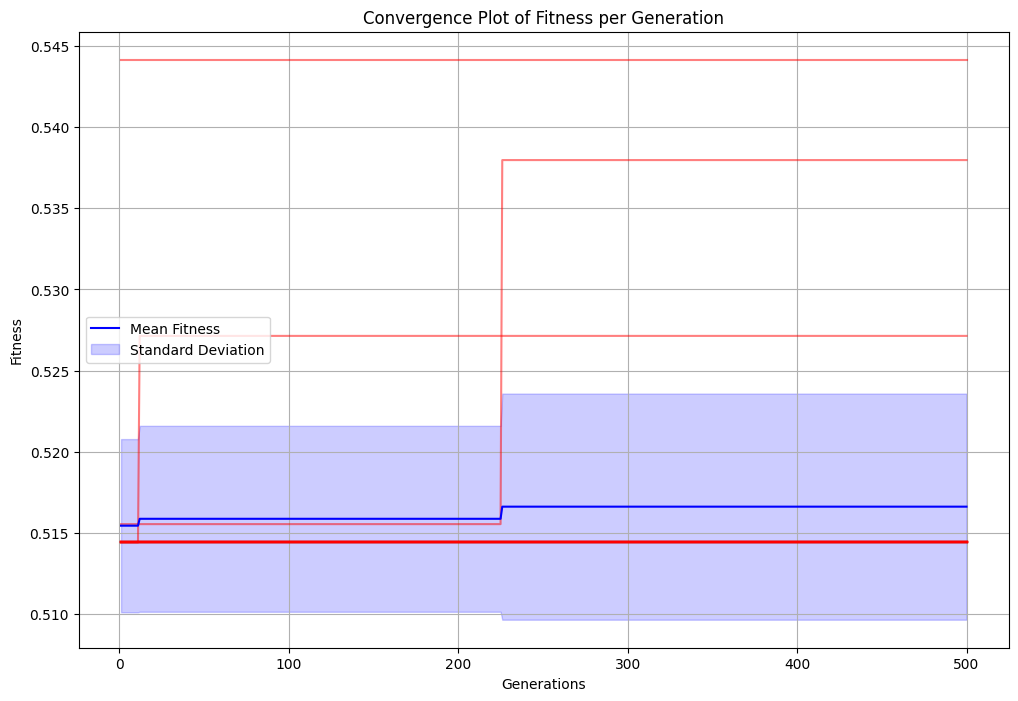

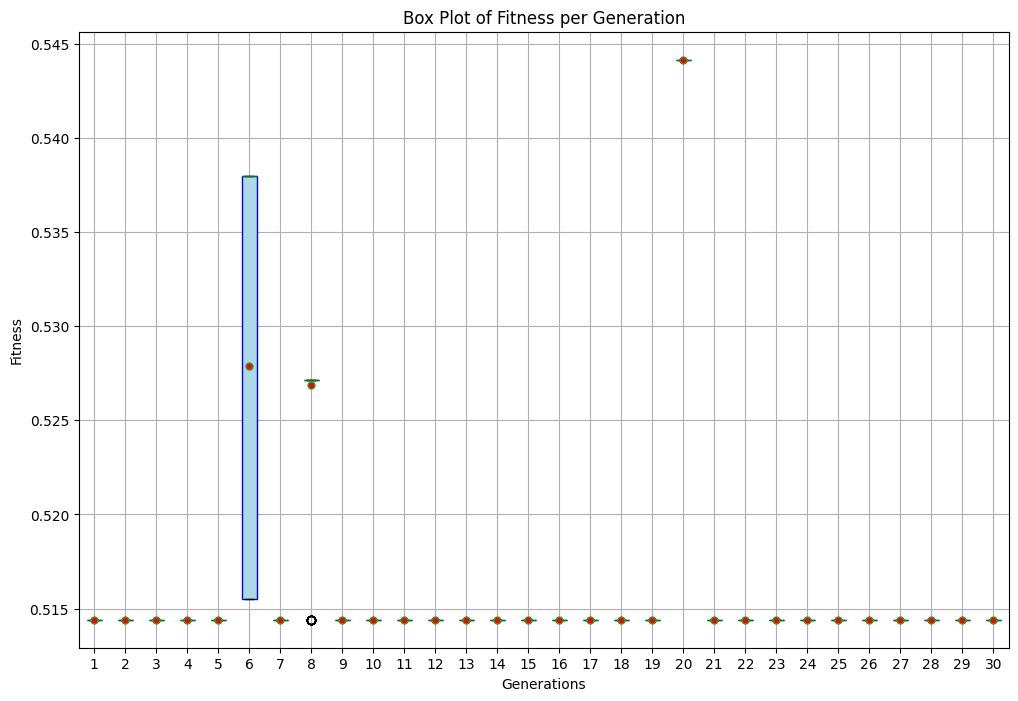

In [26]:
# Cargar y combinar resultados de todos los checkpoints
all_fitness_from_checkpoints = []
for i in range(NUMBER_EXPERIMENTS):
    checkpoint_file = f"checkpoint_{i}.pkl"
    if os.path.exists(checkpoint_file):
        checkpoint = load_checkpoint(checkpoint_file)
        all_fitness_from_checkpoints.append(checkpoint['best_fitness_per_gen'])

# Convertir los valores de fitness en una matriz para las gráficas
max_generations = max(len(fitness) for fitness in all_fitness_from_checkpoints)
generations = np.arange(1, max_generations + 1)
fitness_matrix = np.full((len(all_fitness_from_checkpoints), max_generations), np.nan)

for i, fitness in enumerate(all_fitness_from_checkpoints):
    fitness_matrix[i, :len(fitness)] = fitness

# Graficar el progreso
plt.figure(figsize=(12, 8))
for i in range(fitness_matrix.shape[0]):
    plt.plot(
        generations,
        fitness_matrix[i],
        linestyle='-',
        color='red',
        alpha=0.5
    )

# Calcular estadísticas
mean_fitness = np.nanmean(fitness_matrix, axis=0)
std_fitness = np.nanstd(fitness_matrix, axis=0)

# Graficar la media del fitness
plt.plot(
    generations,
    mean_fitness,
    linestyle='-',
    color='blue',
    label='Mean Fitness'
)

# Rellenar entre la media y la desviación estándar
plt.fill_between(
    generations,
    mean_fitness - std_fitness,
    mean_fitness + std_fitness,
    color='blue',
    alpha=0.2,
    label='Standard Deviation'
)

plt.title('Convergence Plot of Fitness per Generation')
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.show()

# Graficar Box Plot
plt.figure(figsize=(12, 8))
plt.boxplot(
    fitness_matrix.T,  # Transponer para que cada generación sea una caja
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    meanprops=dict(marker='o', markerfacecolor='red', markersize=5),
    medianprops=dict(color='green')
)
plt.title('Box Plot of Fitness per Generation')
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.grid(True)
plt.show()


In [27]:
# Cargar y combinar resultados de todos los checkpoints
all_fitness_from_checkpoints = []
best_individuals = []

for i in range(30):  # Ajusta el rango según el número de experimentos realizados
    checkpoint_file = f"checkpoint_{i}.pkl"
    if os.path.exists(checkpoint_file):
        checkpoint = load_checkpoint(checkpoint_file)
        all_fitness_from_checkpoints.append(checkpoint['best_fitness_per_gen'])
        best_individuals.append(max(checkpoint['population'], key=lambda x: x['fitness']))

# Encontrar el mejor individuo entre todos los experimentos
best_overall_individual = max(best_individuals, key=lambda x: x['fitness'])
print(f"El mejor individuo tiene un fitness de: {best_overall_individual['fitness']}")
print(f"Codificación del mejor individuo: {best_overall_individual['individual']}")


Checkpoint cargado desde checkpoint_0.pkl
Checkpoint cargado desde checkpoint_1.pkl
Checkpoint cargado desde checkpoint_2.pkl
Checkpoint cargado desde checkpoint_3.pkl
Checkpoint cargado desde checkpoint_4.pkl
Checkpoint cargado desde checkpoint_5.pkl
Checkpoint cargado desde checkpoint_6.pkl
Checkpoint cargado desde checkpoint_7.pkl
Checkpoint cargado desde checkpoint_8.pkl
Checkpoint cargado desde checkpoint_9.pkl
Checkpoint cargado desde checkpoint_10.pkl
Checkpoint cargado desde checkpoint_11.pkl
Checkpoint cargado desde checkpoint_12.pkl
Checkpoint cargado desde checkpoint_13.pkl
Checkpoint cargado desde checkpoint_14.pkl
Checkpoint cargado desde checkpoint_15.pkl
Checkpoint cargado desde checkpoint_16.pkl
Checkpoint cargado desde checkpoint_17.pkl
Checkpoint cargado desde checkpoint_18.pkl
Checkpoint cargado desde checkpoint_19.pkl
Checkpoint cargado desde checkpoint_20.pkl
Checkpoint cargado desde checkpoint_21.pkl
Checkpoint cargado desde checkpoint_22.pkl
Checkpoint cargado de

In [34]:
import os
import copy
import json
import csv
import numpy as np
import pandas as pd
import tensorflow as tf
import torchaudio
import torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from keras.models import Sequential, Model
from keras.layers import Resizing, Conv2D, Dropout, BatchNormalization, MaxPooling2D, MaxPool2D, Flatten, Dense, Input, LeakyReLU
from tqdm import tqdm
import tensorflow_addons as tfa

# Configuración de parámetros
class Config:
    def __init__(self, architecture='random', epochs=50, sample_rate=None, time=5, n_splits=5, window_size=5, checkpoint_file="training_checkpoint.json"):
        self.architecture = architecture
        self.epochs = epochs
        self.sample_rate = sample_rate
        self.time = time
        self.n_splits = n_splits
        self.window_size = window_size
        self.checkpoint_file = checkpoint_file

# Crear o cargar checkpoint
def load_checkpoint(file_path):
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            checkpoint = json.load(f)
            print(f"Checkpoint cargado: {checkpoint}")
            return checkpoint
    return {"last_completed": -1}

def save_checkpoint(file_path, architecture_index):
    checkpoint = {"last_completed": architecture_index}
    with open(file_path, 'w') as f:
        json.dump(checkpoint, f)
    print(f"Checkpoint guardado: {checkpoint}")

# Cargar datos de audio
def load_audio_data(directory, window_size, sample_rate):
    audio_dict = {}
    for file_name in os.listdir(directory):
        if file_name.endswith(".wav"):
            waveform, sr = torchaudio.load(os.path.join(directory, file_name))
            if sample_rate is None:
                sample_rate = sr
            num_windows = int(waveform.shape[1] / (window_size * sample_rate))
            for i in range(num_windows):
                start = i * window_size * sample_rate
                end = (i + 1) * window_size * sample_rate
                audio_dict[f"{file_name}_{i}"] = waveform[:, start:end].numpy()
    return audio_dict, sample_rate

# Preprocesar datos de audio
def preprocess_audio(audio_dict, sample_rate):
    audio_dict = copy.deepcopy(audio_dict)
    n_mels = 128
    n_fft = int(sample_rate * 0.029)
    hop_length = int(sample_rate * 0.010)
    win_length = int(sample_rate * 0.025)

    for filename, waveform in tqdm(audio_dict.items(), desc='MELSPECTROGRAM'):
        waveform = torch.from_numpy(waveform)
        spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate, n_fft=n_fft, n_mels=n_mels, hop_length=hop_length, win_length=win_length)(waveform)
        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = spec.numpy()
        spec = (spec - spec.min()) / (spec.max() - spec.min())
        audio_dict[filename] = spec
    return audio_dict

# Padding de los espectrogramas
def pad_and_crop_spectrograms(spectrograms, target_shape=(128, 128)):
    padded_spectrograms = []
    for spec in spectrograms:
        if spec.shape[0] > target_shape[0]:
            spec = spec[:target_shape[0], :]
        if spec.shape[1] > target_shape[1]:
            spec = spec[:, :target_shape[1]]
        
        pad_width = [(0, max(0, target_shape[0] - spec.shape[0])), 
                     (0, max(0, target_shape[1] - spec.shape[1]))]
        
        padded_spec = np.pad(spec, pad_width, mode='constant')
        padded_spectrograms.append(padded_spec)
    return np.array(padded_spectrograms)

# Split de audio en train y test
def train_test_split_audio(audio_dict):
    df = pd.read_csv('Dataset.csv', usecols=['Participant_ID', 'PHQ-9 Score'], dtype={1: str})
    df['labels'] = np.zeros([len(df),], dtype=int)
    df.loc[df['PHQ-9 Score'] < 10, 'labels'] = 0
    df.loc[df['PHQ-9 Score'] >= 10, 'labels'] = 1

    labels = df.set_index('Participant_ID').to_dict()['labels']

    X, Y = [], []
    for filename, data in tqdm(audio_dict.items(), 'LABEL'):
        ID = filename[:3]
        if ID in labels:
            dep = 0 if labels[ID] == 0 else 1
            [X.append(x) for x in data]
            [Y.append(dep) for x in data]

    X = pad_and_crop_spectrograms(X)
    Y = np.array(Y)

    X = X[..., np.newaxis]
    print(f"X shape: {X.shape}, Y shape: {Y.shape}")
    return X, Y

# Guardar resultados en CSV (append)
def append_results_to_csv(file_path, model_results):
    columns = ["Encoded Architecture", "Loss", "Accuracy", "Precision", "Recall", "F1", "Specificity"]

    # Convertir arquitectura a cadena para guardar
    model_results = [str(model_results[0])] + model_results[1:]

    # Verificar si el archivo ya existe
    if not os.path.exists(file_path):
        # Crear archivo con encabezados si no existe
        with open(file_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(columns)

    # Escribir resultados en el archivo
    with open(file_path, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(model_results)
    print(f"Resultados guardados en: {file_path}")

# Función de especificidad
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Entrenar y evaluar modelo
def train_and_evaluate_model(model, X_train, Y_train, X_val, Y_val, X_test, Y_test, config):
    model.compile(optimizer='adadelta', loss='binary_crossentropy', metrics=["accuracy", 'Precision', 'Recall'])
    model.fit(X_train, Y_train, epochs=config.epochs, validation_data=(X_val, Y_val), verbose=0)
    results = model.evaluate(X_test, Y_test, verbose=0)

    # Obtener predicciones para métricas adicionales
    Y_pred = (model.predict(X_test) > 0.5).astype("int32")
    accuracy = results[1]
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    specificity = specificity_score(Y_test, Y_pred)

    return [results[0], accuracy, precision, recall, f1, specificity]

# Evaluar y almacenar resultados
def evaluate_and_store_model(architecture, X_train_val, X_test, Y_train_val, Y_test, config, use_kfold, stratified_kfold, target_shape, results_file):
    repaired_architecture = fixArch(architecture)
    decoded_model_dict = decode_model_architecture(repaired_architecture)
    model_results = [repaired_architecture]

    if use_kfold:
        fold_results = []
        for fold, (train_index, val_index) in enumerate(stratified_kfold.split(X_train_val, Y_train_val)):
            print(f"Entrenando fold {fold + 1}/{config.n_splits}...")
            X_train, X_val = X_train_val[train_index], X_train_val[val_index]
            Y_train, Y_val = Y_train_val[train_index], Y_train_val[val_index]
            tf_model = build_tf_model_from_dict(decoded_model_dict, input_shape=(target_shape[0], target_shape[1], 1))
            fold_results.append(train_and_evaluate_model(tf_model, X_train, Y_train, X_val, Y_val, X_test, Y_test, config))
            print(f"Fold {fold + 1} completado.")

        avg_results = np.mean(fold_results, axis=0)
        model_results.extend(avg_results)

    else:
        X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.2, random_state=42)
        tf_model = build_tf_model_from_dict(decoded_model_dict, input_shape=(target_shape[0], target_shape[1], 1))
        single_run_results = train_and_evaluate_model(tf_model, X_train, Y_train, X_val, Y_val, X_test, Y_test, config)
        model_results.extend(single_run_results)
        print("Modelo evaluado sin K-Fold Cross Validation.")

    # Guardar métricas de la arquitectura actual en el archivo CSV
    append_results_to_csv(results_file, model_results)



In [28]:
import numpy as np
import pandas as pd
import tensorflow as tf
import torchaudio
import torch
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
import copy
import os

# Función de especificidad
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Entrenar y evaluar modelo
def train_and_evaluate_model(model, X_train, Y_train, X_val, Y_val, X_test, Y_test, epochs):
    model.compile(optimizer='adadelta', loss='binary_crossentropy', metrics=["accuracy", 'Precision', 'Recall'])
    model.fit(X_train, Y_train, epochs=epochs, validation_data=(X_val, Y_val), verbose=0)
    results = model.evaluate(X_test, Y_test, verbose=0)

    # Obtener predicciones para métricas adicionales
    Y_pred = (model.predict(X_test) > 0.5).astype("int32")
    accuracy = results[1]
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    specificity = specificity_score(Y_test, Y_pred)

    return [results[0], accuracy, precision, recall, f1, specificity]

# Evaluar y almacenar resultados
def evaluate_best_individual(best_individual, X_train_val, X_test, Y_train_val, Y_test, target_shape, epochs=50, n_splits=5):
    # Decodificar la arquitectura
    repaired_architecture = fixArch(best_individual)
    decoded_model_dict = decode_model_architecture(repaired_architecture)

    fold_results = []
    stratified_kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_index, val_index) in enumerate(stratified_kfold.split(X_train_val, Y_train_val)):
        print(f"Entrenando fold {fold + 1}/{n_splits}...")
        X_train, X_val = X_train_val[train_index], X_train_val[val_index]
        Y_train, Y_val = Y_train_val[train_index], Y_train_val[val_index]
        
        # Crear el modelo a partir de la arquitectura
        tf_model = build_tf_model_from_dict(decoded_model_dict, input_shape=(target_shape[0], target_shape[1], 1))
        fold_results.append(train_and_evaluate_model(tf_model, X_train, Y_train, X_val, Y_val, X_test, Y_test, epochs))
        print(f"Fold {fold + 1} completado.")

    avg_results = np.mean(fold_results, axis=0)
    print(f"Resultados promedio en {n_splits} folds: Loss={avg_results[0]:.4f}, Accuracy={avg_results[1]:.4f}, Precision={avg_results[2]:.4f}, Recall={avg_results[3]:.4f}, F1={avg_results[4]:.4f}, Specificity={avg_results[5]:.4f}")

# Preprocesamiento de datos de audio
def load_audio_data(directory, window_size, sample_rate):
    audio_dict = {}
    for file_name in os.listdir(directory):
        if file_name.endswith(".wav"):
            waveform, sr = torchaudio.load(os.path.join(directory, file_name))
            if sample_rate is None:
                sample_rate = sr
            num_windows = int(waveform.shape[1] / (window_size * sample_rate))
            for i in range(num_windows):
                start = i * window_size * sample_rate
                end = (i + 1) * window_size * sample_rate
                audio_dict[f"{file_name}_{i}"] = waveform[:, start:end].numpy()
    return audio_dict, sample_rate

def preprocess_audio(audio_dict, sample_rate):
    audio_dict = copy.deepcopy(audio_dict)
    n_mels = 128
    n_fft = int(sample_rate * 0.029)
    hop_length = int(sample_rate * 0.010)
    win_length = int(sample_rate * 0.025)

    for filename, waveform in tqdm(audio_dict.items(), desc='MELSPECTROGRAM'):
        waveform = torch.from_numpy(waveform)
        spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate, n_fft=n_fft, n_mels=n_mels, hop_length=hop_length, win_length=win_length)(waveform)
        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = spec.numpy()
        spec = (spec - spec.min()) / (spec.max() - spec.min())
        audio_dict[filename] = spec
    return audio_dict

def pad_and_crop_spectrograms(spectrograms, target_shape=(128, 128)):
    padded_spectrograms = []
    for spec in spectrograms:
        if spec.shape[0] > target_shape[0]:
            spec = spec[:target_shape[0], :]
        if spec.shape[1] > target_shape[1]:
            spec = spec[:, :target_shape[1]]
        
        pad_width = [(0, max(0, target_shape[0] - spec.shape[0])), 
                     (0, max(0, target_shape[1] - spec.shape[1]))]
        
        padded_spec = np.pad(spec, pad_width, mode='constant')
        padded_spectrograms.append(padded_spec)
    return np.array(padded_spectrograms)

def train_test_split_audio(audio_dict):
    df = pd.read_csv('Dataset.csv', usecols=['Participant_ID', 'PHQ-9 Score'], dtype={1: str})
    df['labels'] = np.zeros([len(df),], dtype=int)
    df.loc[df['PHQ-9 Score'] < 10, 'labels'] = 0
    df.loc[df['PHQ-9 Score'] >= 10, 'labels'] = 1

    labels = df.set_index('Participant_ID').to_dict()['labels']

    X, Y = [], []
    for filename, data in tqdm(audio_dict.items(), 'LABEL'):
        ID = filename[:3]
        if ID in labels:
            dep = 0 if labels[ID] == 0 else 1
            [X.append(x) for x in data]
            [Y.append(dep) for x in data]

    X = pad_and_crop_spectrograms(X)
    Y = np.array(Y)

    X = X[..., np.newaxis]
    print(f"X shape: {X.shape}, Y shape: {Y.shape}")
    return X, Y

# Cargar datos
directory = './SM-27'  # Ruta a los archivos de audio
window_size = 5  # Tamaño de la ventana en segundos
sample_rate = None  # Se determinará en la carga

print("Cargando y preprocesando datos de audio...")
audio_dict, sample_rate = load_audio_data(directory, window_size, sample_rate)
audio_dict = preprocess_audio(audio_dict, sample_rate)
X, Y = train_test_split_audio(audio_dict)

X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Evaluar el mejor individuo (sustituye 'best_overall_individual' con la arquitectura específica)
evaluate_best_individual(
    best_overall_individual['individual'],
    X_train_val,
    X_test,
    Y_train_val,
    Y_test,
    target_shape=(128, 128),
    epochs=100,
    n_splits=5
)


Cargando y preprocesando datos de audio...


LABEL: 100%|██████████| 5890/5890 [00:00<00:00, 619827.15it/s]


X shape: (5890, 128, 128, 1), Y shape: (5890,)
Entrenando fold 1/5...

Construyendo el modelo en TensorFlow desde el JSON expandido...
37/37 [==============================] - 0s 7ms/step
Fold 1 completado.
Entrenando fold 2/5...

Construyendo el modelo en TensorFlow desde el JSON expandido...


c:\Users\herna\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


37/37 [==============================] - 0s 8ms/step
Fold 2 completado.
Entrenando fold 3/5...

Construyendo el modelo en TensorFlow desde el JSON expandido...


...

c:\Users\herna\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


37/37 [==============================] - 0s 7ms/step
Fold 4 completado.
Entrenando fold 5/5...

Construyendo el modelo en TensorFlow desde el JSON expandido...


c:\Users\herna\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


37/37 [==============================] - 0s 7ms/step
Fold 5 completado.
Resultados promedio en 5 folds: Loss=0.6919, Accuracy=0.5255, Precision=0.0000, Recall=0.0000, F1=0.0000, Specificity=1.0000


c:\Users\herna\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
best_individual = best_overall_individual['individual']
constructed_model = build_tf_model_from_dict(decode_model_architecture(best_individual))
print(constructed_model.summary())



Construyendo el modelo en TensorFlow desde el JSON expandido...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 4)         1156      
                                                                 
 dont_care_layer (DontCareLa  (None, 28, 28, 4)        0         
 yer)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 4)         148       
                                                                 
 conv2d_3 (Conv2D)           (None, 28, 28, 4)         148       
                                                                 
 conv2d_4 (Conv2D)           (None, 28, 28, 4)         14

In [23]:
import os

def delete_checkpoints(folder_path, checkpoint_prefix="checkpoint_", super_checkpoint_file="super_checkpoint.pkl"):
    """
    Elimina todos los archivos de checkpoint y supracheckpoint.

    Args:
        folder_path (str): Ruta del directorio donde se encuentran los checkpoints.
        checkpoint_prefix (str): Prefijo de los archivos de checkpoint.
        super_checkpoint_file (str): Nombre del archivo de supracheckpoint.
    """
    # Borrar checkpoints individuales
    for filename in os.listdir(folder_path):
        if filename.startswith(checkpoint_prefix):
            file_path = os.path.join(folder_path, filename)
            try:
                os.remove(file_path)
                print(f"Eliminado: {file_path}")
            except Exception as e:
                print(f"Error al eliminar {file_path}: {e}")
    
    # Borrar supracheckpoint
    super_checkpoint_path = os.path.join(folder_path, super_checkpoint_file)
    if os.path.exists(super_checkpoint_path):
        try:
            os.remove(super_checkpoint_path)
            print(f"Eliminado: {super_checkpoint_path}")
        except Exception as e:
            print(f"Error al eliminar {super_checkpoint_path}: {e}")

# Ejecutar la función
delete_checkpoints(".", checkpoint_prefix="checkpoint_", super_checkpoint_file="super_checkpoint.pkl")


Eliminado: .\checkpoint_0.pkl
Eliminado: .\checkpoint_1.pkl
Eliminado: .\checkpoint_10.pkl
Eliminado: .\checkpoint_11.pkl
Eliminado: .\checkpoint_12.pkl
Eliminado: .\checkpoint_13.pkl
Eliminado: .\checkpoint_14.pkl
Eliminado: .\checkpoint_15.pkl
Eliminado: .\checkpoint_16.pkl
Eliminado: .\checkpoint_17.pkl
Eliminado: .\checkpoint_18.pkl
Eliminado: .\checkpoint_19.pkl
Eliminado: .\checkpoint_2.pkl
Eliminado: .\checkpoint_20.pkl
Eliminado: .\checkpoint_21.pkl
Eliminado: .\checkpoint_22.pkl
Eliminado: .\checkpoint_23.pkl
Eliminado: .\checkpoint_24.pkl
Eliminado: .\checkpoint_25.pkl
Eliminado: .\checkpoint_26.pkl
Eliminado: .\checkpoint_27.pkl
Eliminado: .\checkpoint_28.pkl
Eliminado: .\checkpoint_29.pkl
Eliminado: .\checkpoint_3.pkl
Eliminado: .\checkpoint_4.pkl
Eliminado: .\checkpoint_5.pkl
Eliminado: .\checkpoint_6.pkl
Eliminado: .\checkpoint_7.pkl
Eliminado: .\checkpoint_8.pkl
Eliminado: .\checkpoint_9.pkl
Eliminado: .\super_checkpoint.pkl
